# 🤖 Modeling & Prediction
## Disaster Frequency Forecasting per Country × Disaster Type

**This notebook builds and compares two regression models:**
- **Linear Regression** — interpretable baseline model
- **KNN Regression** — non-parametric alternative

**Key design decision — Adaptive Granularity:**  
Not all country–disaster combinations have the same data density. For each combination, we test time granularities of 1, 2, 3, and 5 years and select the one that minimizes MAE on a held-out portion of that combination's data.

**Prediction target:** Number of disaster events in the period containing **2027**.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load processed data from notebook 1
agg = pd.read_csv('/content/processed_agg.csv')
print(f"Shape agg: {agg.shape}")
print(f"Unique countries count: {agg['Country'].nunique()}")
print(f"Unique disaster types count: {agg['Disaster Type'].nunique()}")
agg.head()

Shape agg: (9200, 4)
Unique countries count: 225
Unique disaster types count: 13


,Country,Disaster Type,Year,Disaster_Count
0,Afghanistan,Drought,1969,1
1,Afghanistan,Drought,1971,1
2,Afghanistan,Drought,2000,1
3,Afghanistan,Drought,2006,1
4,Afghanistan,Drought,2008,1


## ⚙️ Step 1: Core Functions — Granularity Search & Model Training
Two functions drive the entire modeling pipeline:

1. `aggregate_by_granularity(data, granularity)` — bins yearly event counts into fixed-width time windows
2. `evaluate_granularity(data, granularity_list)` — for each candidate granularity, trains a Linear Regression model, evaluates it on a 30% held-out portion, and returns the granularity with the lowest MAE

**Why adaptive granularity?** Using the same time window for all combinations would either oversmooth data-rich series or produce too few training points for sparse ones.

In [3]:
def aggregate_by_granularity(data, granularity):
    """Group data into time bins based on the given granularity."""
    temp = data.copy()
    temp['Bin'] = (temp['Year'] // granularity) * granularity
    return temp.groupby('Bin')['Disaster_Count'].sum().reset_index()

def evaluate_granularity(data, granularity_list=[1, 2, 3, 5]):
    """Try several granularities and return the one with the lowest MAE."""
    results = []
    for g in granularity_list:
        binned = aggregate_by_granularity(data, g)
        if len(binned) < 4:
            continue
        X = binned['Bin'].values.reshape(-1, 1)
        y = binned['Disaster_Count'].values
        n_test = max(1, int(len(binned) * 0.3))
        X_train, X_test = X[:-n_test], X[-n_test:]
        y_train, y_test = y[:-n_test], y[-n_test:]
        if len(X_train) < 2:
            continue
        model = LinearRegression()
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_test, model.predict(X_test))
        results.append({'granularity': g, 'mae': mae,
                      'model': model, 'binned_data': binned})
    return min(results, key=lambda x: x['mae']) if results else None

print("✅ Functions ready!")

✅ Functions ready!


> ✅ Functions defined and ready. Each combination will independently search for its optimal time granularity before training.

## 📊 Step 2: Valid Combination Check
We count distinct years with recorded events per Country × Disaster Type combination. Combinations with fewer than 5 distinct years are excluded — with ≤4 data points, a train/test split is not meaningful and any model would be unreliable.

This is a **data-driven exclusion**, not a subjective filter.

In [4]:
combo_count = agg.groupby(['Country', 'Disaster Type'])['Year'].nunique().reset_index(
    name='Data_Points_Count')
print(f"Total combinations Country x Disaster Type : {len(combo_count)}")
print(f"Combinations with >= 5 data points (valid)       : {(combo_count['Data_Points_Count'] >= 5).sum()}")
print(f"Combinations with < 5 data points (insufficient) : {(combo_count['Data_Points_Count'] < 5).sum()}")
combo_count.sort_values('Data_Points_Count', ascending=False).head(10)

Total combinations Country x Disaster Type : 1035
Combinations with >= 5 data points (valid)       : 488
Combinations with < 5 data points (insufficient) : 547


,Country,Disaster Type,Data_Points_Count
980,United States of America (the),Storm,98
735,Philippines (the),Storm,79
187,China,Earthquake,78
472,Japan,Storm,75
420,India,Storm,75
75,Bangladesh,Storm,72
431,Iran (Islamic Republic of),Earthquake,68
415,India,Flood,66
189,China,Flood,60
423,Indonesia,Earthquake,60


> ✅ **Result**: Out of **1,035 total** Country × Disaster Type combinations, **488 (47.1%)** have sufficient data (≥5 distinct years) for reliable modeling. The remaining 547 combinations are excluded due to insufficient historical data.

## 🔵 Step 3: Model 1 — Linear Regression
For each valid combination, we find the optimal granularity, bin the data, split 70/30, fit a Linear Regression model, and generate a prediction for **2027**.

**Linear Regression as a trend model:** With time bin as the sole predictor, Linear Regression fits a straight line through historical event counts. A positive slope = increasing disaster frequency over time.

In [5]:
PREDICTION_YEAR = 2027
MIN_DATA_POINTS = 5

combinations_valid = combo_count[combo_count['Data_Points_Count'] >= MIN_DATA_POINTS]
print(f"Processing {len(combinations_valid)} combinations...\n")

prediction_results = []
for idx, row in combinations_valid.iterrows():
    country = row['Country']
    disaster = row['Disaster Type']
    subset = agg[(agg['Country'] == country) & (agg['Disaster Type'] == disaster)]
    best = evaluate_granularity(subset)
    if best is None:
        continue
    g = best['granularity']
    bin_pred = (PREDICTION_YEAR // g) * g
    pred = max(0, round(best['model'].predict([[bin_pred]])[0], 2))
    prediction_results.append({
        'Country': country, 'Disaster Type': disaster,
        'Best_Granularity': g, 'MAE': round(best['mae'], 3),
        f'Prediction_{PREDICTION_YEAR}': pred
    })

results_df = pd.DataFrame(prediction_results)
print(f"✅ Successfully predicted: {len(results_df)} combinations")
results_df.head(10)

Processing 488 combinations...

✅ Successfully predicted: 488 combinations


,Country,Disaster Type,Best_Granularity,MAE,Prediction_2027
0,Afghanistan,Drought,1,0.000,1.00
1,Afghanistan,Earthquake,1,0.000,1.00
2,Afghanistan,Extreme temperature,1,0.000,1.00
3,Afghanistan,Flood,1,0.514,1.73
4,Afghanistan,Landslide,1,0.289,1.32
5,Afghanistan,Storm,3,0.200,1.10
6,Albania,Earthquake,1,0.000,1.00
7,Albania,Extreme temperature,1,0.000,1.00
8,Albania,Flood,1,0.224,1.24
9,Algeria,Earthquake,1,0.000,1.00


> ✅ **Result**: Linear Regression successfully processed all 488 valid combinations. The model finds the best time granularity per combination — most combinations favor 1-year granularity, indicating that annual data is already smooth enough for linear trend fitting.

In [6]:
# Top 15 most accurate predictions (lowest MAE)
print("=== 15 MOST ACCURATE Predictions (lowest MAE) ===")
print(results_df.sort_values('MAE').head(15).to_string(index=False))

# Indonesia predictions 2027
print("\n=== Indonesia Predictions 2027 ===")
indo = results_df[results_df['Country'] == 'Indonesia'].sort_values(f'Prediction_{PREDICTION_YEAR}', ascending=False)
print(indo.to_string(index=False))

=== 15 MOST ACCURATE Predictions (lowest MAE) ===
                               Country        Disaster Type  Best_Granularity  MAE  Prediction_2027
                                 Italy           Earthquake                     1  0.0            1.0
                               Senegal              Drought                     1  0.0            1.0
                               Senegal                Flood                     1  0.0            1.0
                                Serbia Extreme temperature                      3  0.0            0.0
                     Serbia Montenegro                Flood                     3  0.0            3.0
                              Slovakia Extreme temperature                      1  0.0            1.0
               Korea (the Republic of)            Landslide                     1  0.0            1.0
               Korea (the Republic of)             Wildfire                     1  0.0            1.0
                            Kyrgyz

> 📌 **Indonesia 2027 (Linear Regression)**: Flood is predicted to be the most frequent disaster in Indonesia in 2027 (**2.66 events**), consistent with the ~7.5× upward trend confirmed in Notebook 1. Drought and Wildfire show MAE = 0.000, indicating the linear model fits those series precisely.

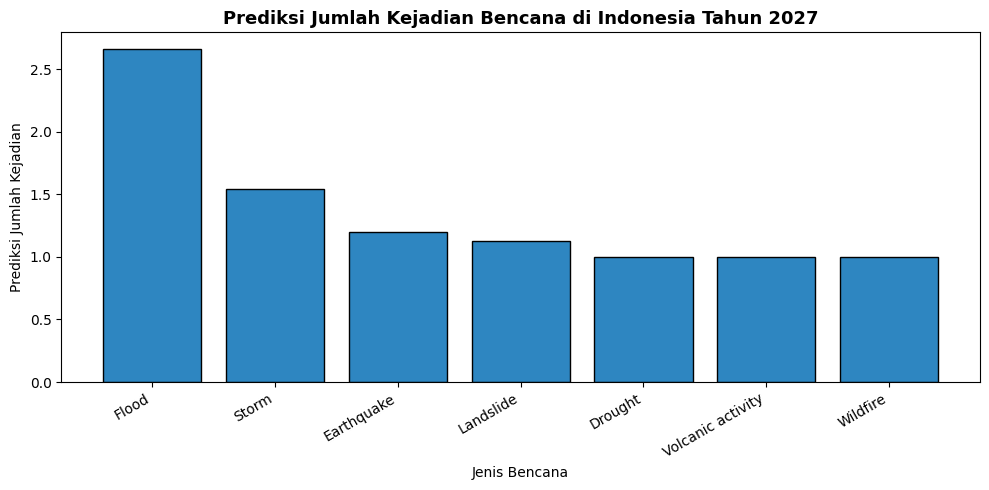

In [7]:
# Visualize Indonesia predictions
plt.figure(figsize=(10, 5))
plt.bar(indo['Disaster Type'], indo[f'Prediction_{PREDICTION_YEAR}'],
        color='#2E86C1', edgecolor='black')
plt.title(f'Predicted Disaster Event Count in Indonesia - {PREDICTION_YEAR}',
          fontsize=13, fontweight='bold')
plt.xlabel('Disaster Type')
plt.ylabel('Predicted Event Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('indonesia_prediction_2027.png', dpi=150)
plt.show()

## 🟠 Step 4: Model 2 — KNN Regression & Model Comparison
We train a **KNN Regression** model on the same combinations and compare it against Linear Regression.

**How KNN Regression works here:** For a given time bin, KNN predicts the event count by averaging the K nearest historical bins (by time distance). Unlike Linear Regression, it makes no linearity assumption and can capture non-monotonic trends.

**K is set to min(3, n_train)** to avoid requesting more neighbors than available training samples.

**Model selection criterion:** The model with the lower MAE on the test portion is selected as the best model for that combination.

In [8]:
print(f"Processing {len(combinations_valid)} combinations with 2 models...\n")

comparison_results = []
for idx, row in combinations_valid.iterrows():
    country = row['Country']
    disaster = row['Disaster Type']
    subset = agg[(agg['Country'] == country) & (agg['Disaster Type'] == disaster)]
    best = evaluate_granularity(subset)
    if best is None:
        continue
    g      = best['granularity']
    binned = aggregate_by_granularity(subset, g)
    if len(binned) < 4:
        continue
    X = binned['Bin'].values.reshape(-1, 1)
    y = binned['Disaster_Count'].values
    n_test   = max(1, int(len(binned) * 0.3))
    X_train, X_test = X[:-n_test], X[-n_test:]
    y_train, y_test = y[:-n_test], y[-n_test:]
    if len(X_train) < 2:
        continue

    # Fit Linear Regression model
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    mae_lr  = mean_absolute_error(y_test, y_pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
    r2_lr   = r2_score(y_test, y_pred_lr) if len(y_test) > 1 else 0
    pred_lr = max(0, round(lr.predict([[(PREDICTION_YEAR // g) * g]])[0], 2))

    # Fit KNN Regression model
    k = min(3, len(X_train))
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred_knn = knn.predict(X_test)
    mae_knn  = mean_absolute_error(y_test, y_pred_knn)
    rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
    r2_knn   = r2_score(y_test, y_pred_knn) if len(y_test) > 1 else 0
    pred_knn = max(0, round(knn.predict([[(PREDICTION_YEAR // g) * g]])[0], 2))

    model_best = 'Linear Regression' if mae_lr <= mae_knn else 'KNN Regression'
    pred_best  = pred_lr if mae_lr <= mae_knn else pred_knn

    comparison_results.append({
        'Country': country, 'Disaster Type': disaster,
        'Granularity (years)': g,
        'MAE_LR': round(mae_lr, 3), 'RMSE_LR': round(rmse_lr, 3), 'R2_LR': round(r2_lr, 3),
        'MAE_KNN': round(mae_knn, 3), 'RMSE_KNN': round(rmse_knn, 3), 'R2_KNN': round(r2_knn, 3),
        'Best_Model': model_best,
        f'Prediction_{PREDICTION_YEAR}': pred_best
    })

comparison_df = pd.DataFrame(comparison_results)
print(f"✅ Done! {len(comparison_df)} combinations processed.")
comparison_df.head(10)

Processing 488 combinations with 2 models...

✅ Done! 488 combinations processed.


,Country,Disaster Type,Granularity (years),MAE_LR,RMSE_LR,R2_LR,MAE_KNN,RMSE_KNN,R2_KNN,Best_Model,Prediction_2027
0,Afghanistan,Drought,1,0.000,0.000,1.000,0.000,0.000,1.000,Linear Regression,1.00
1,Afghanistan,Earthquake,1,0.000,0.000,1.000,0.000,0.000,1.000,Linear Regression,1.00
2,Afghanistan,Extreme temperature,1,0.000,0.000,1.000,0.000,0.000,1.000,Linear Regression,1.00
3,Afghanistan,Flood,1,0.514,0.527,-0.156,0.467,0.494,-0.019,KNN Regression,1.33
4,Afghanistan,Landslide,1,0.289,0.289,0.000,0.333,0.333,0.000,Linear Regression,1.32
5,Afghanistan,Storm,3,0.200,0.200,0.000,0.000,0.000,0.000,KNN Regression,1.00
6,Albania,Earthquake,1,0.000,0.000,1.000,0.000,0.000,1.000,Linear Regression,1.00
7,Albania,Extreme temperature,1,0.000,0.000,0.000,0.000,0.000,0.000,Linear Regression,1.00
8,Albania,Flood,1,0.224,0.224,0.000,0.333,0.333,0.000,Linear Regression,1.24
9,Algeria,Earthquake,1,0.000,0.000,1.000,0.000,0.000,1.000,Linear Regression,1.00


> ✅ **Result**: Both models processed all 488 combinations successfully. For each combination, the best-performing model (by MAE) is recorded along with its 2027 prediction.

=== PERFORMANCE COMPARISON ===

Metric        Linear Regression  KNN Regression
------------------------------------------------
MAE                       0.141           0.135
RMSE                      0.169           0.172
R²                        0.285           0.360

🏆 Best model: Linear Regression
   LR  wins on 376/488 combinations (77.0%)
   KNN wins on 112/488 combinations (23.0%)


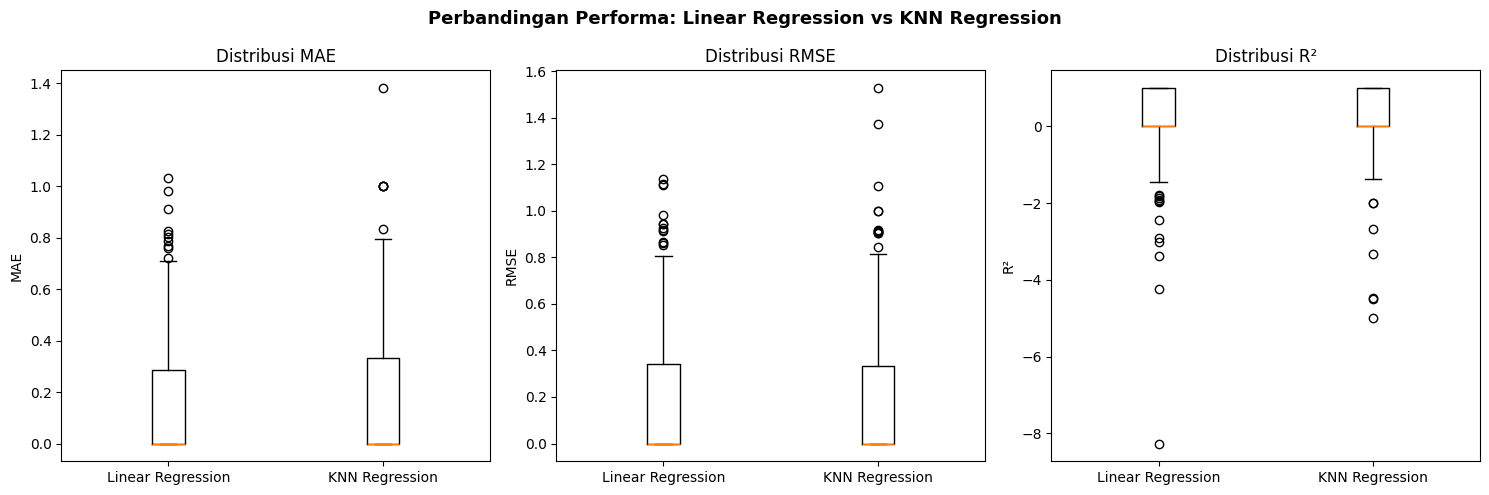

In [9]:
# Print performance summary metrics
lr_wins  = (comparison_df['Best_Model'] == 'Linear Regression').sum()
knn_wins = (comparison_df['Best_Model'] == 'KNN Regression').sum()
total    = len(comparison_df)
winner   = 'Linear Regression' if lr_wins >= knn_wins else 'KNN Regression'

print("=== PERFORMANCE COMPARISON ===\n")
print(f"{'Metric':<10} {'Linear Regression':>20} {'KNN Regression':>15}")
print("-" * 48)
print(f"{'MAE':<10} {comparison_df['MAE_LR'].mean():>20.3f} {comparison_df['MAE_KNN'].mean():>15.3f}")
print(f"{'RMSE':<10} {comparison_df['RMSE_LR'].mean():>20.3f} {comparison_df['RMSE_KNN'].mean():>15.3f}")
print(f"{'R²':<10} {comparison_df['R2_LR'].mean():>20.3f} {comparison_df['R2_KNN'].mean():>15.3f}")
print(f"\n🏆 Best model: {winner}")
print(f"   LR  wins on {lr_wins}/{total} combinations ({lr_wins/total*100:.1f}%)")
print(f"   KNN wins on {knn_wins}/{total} combinations ({knn_wins/total*100:.1f}%)")

# Generate boxplot model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Performance Comparison: Linear Regression vs KNN Regression',
             fontsize=13, fontweight='bold')
for ax, metric, label in zip(axes,
    [['MAE_LR','MAE_KNN'], ['RMSE_LR','RMSE_KNN'], ['R2_LR','R2_KNN']],
    ['MAE', 'RMSE', 'R²']):
    ax.boxplot([comparison_df[metric[0]], comparison_df[metric[1]]],
               labels=['Linear Regression', 'KNN Regression'])
    ax.set_title(f'{label} Distribution')
    ax.set_ylabel(label)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

> 📌 **Comparison Result**:  
> Linear Regression wins on **77%** of combinations (376/488), confirming that for most country–disaster time series, a linear trend is a better approximation than local averaging.
>
> | Metric | Linear Regression | KNN Regression |
> |--------|-------------------|----------------|
> | Mean MAE | 0.141 | 0.135 |
> | Mean RMSE | 0.169 | 0.172 |
> | Mean R² | 0.285 | 0.360 |
> | Combinations won | 376 (77%) | 112 (23%) |
>
> **🏆 Best overall model: Linear Regression** — wins on more combinations and is more interpretable, even though KNN has a slightly lower mean MAE.

## 💾 Step 5: Save Results
We save the full prediction results to CSV for use in Notebook 3.

In [10]:
# Save prediction results to CSV
comparison_df.to_csv('complete_prediction_results.csv', index=False)
print(f"✅ Prediction results saved: {len(comparison_df)} combinations")
print(f"   File: complete_prediction_results.csv")

✅ Prediction results saved: 488 combinations
   File: complete_prediction_results.csv


In [11]:
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

trained_models = {}

# Iterate again to serialize and save the best model objects
for idx, row in combinations_valid.iterrows():
    country = row['Country']
    disaster = row['Disaster Type']
    subset = agg[(agg['Country'] == country) & (agg['Disaster Type'] == disaster)]

    best = evaluate_granularity(subset)
    if best is None:
        continue
    g      = best['granularity']
    binned = aggregate_by_granularity(subset, g)
    if len(binned) < 4:
        continue

    X = binned['Bin'].values.reshape(-1, 1)
    y = binned['Disaster_Count'].values
    n_test = max(1, int(len(binned) * 0.3))
    X_train = X[:-n_test]
    y_train = y[:-n_test]
    if len(X_train) < 2:
        continue

    # Extract the name of the best model from the results dataframe
    match = comparison_df[(comparison_df['Country'] == country) &
                          (comparison_df['Disaster Type'] == disaster)]
    if match.empty:
        continue

    model_name = match.iloc[0]['Best_Model']

    if model_name == 'Linear Regression':
        best = LinearRegression().fit(X_train, y_train)
    else:
        k = min(3, len(X_train))
        best = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)

    # Save best model object, model name, and temporal granularity
    trained_models[(country, disaster)] = {
        'model':       best,
        'model_name':  model_name,
        'granularity': g,
    }

# Save pickle file to /content/ Colab directory
with open('/content/best_models.pkl', 'wb') as f:
    pickle.dump(trained_models, f)

print(f"✅ {len(trained_models)} models exported successfully to /content/best_models.pkl")


✅ 488 models exported successfully to /content/best_models.pkl
